<h1 style="color:green;">Diabetes Medication Clinical Trail Analysis</h1>

<h2 style="color:blue;">Pharma Tech Clinical Study</h2>
<p style="color:black;">This project analyses clinical trial data for a new diabetes medication to eveluate its effectiveness, safety profile, and overall performance compared to a placebo.</p>

<h2 style="color:blue;">Medical Understanding</h2>
<p style="color:black;">Pharma Tech is conducting a clinical trial to assess the effectiveness and safety of a new diabetes medication. The goal is to determine whether the drug provides meaningful improvement in patient health outcomes while maintaining an acceptable safety profile.</p>
<p style="color:black;"> This analysis focuses on evaluating treatment efficacy, identifying potential risks, and support data-driven decision-making in Pharmaceutical development.</p>

<h2 style="color:blue;">Objectives</h2>
<h3 style="color:black;">The manin objectives of this analysis are:</h3>
<p style="color:black;">-Evaluate whether the medication reduces HbA1c levels compared to the Placebo.</p>
<p style="color:black;">-Analyse differences in treatment effectiveness across patient demographics.</p>
<p style="color:black;">-Assess the safety profile of the medication by examining adverse effects.</p>
<p style="color:black;">-Investigate the relationship between the duration of diabetes and treatment effectiveness.</p>

<h2 style="color:blue;">Research Questions</h2>
<h3 style="color:black;">This analysis aims to answer the following key questions:</h3>

<p style="color:black;">1. Is the new medication effective in reducing HbA1c levels compared to the Placebo?</p>
<p style="color:black;">2.Are there significant differences in effectiveness across patient demographics?</p>
<p style="color:black;">3.What is the safety profile of the medication?</p>
<p style="color:black;">4.Are there any concerning adverse effects?</p>
<p style="color:black;">5.Is there a relatioship between duration of diabetes and medication effectiveness?</p>


<h3 style="color:black;"> Importing Libraries and Loading Dataset</h3>


In [5]:
import pandas as pd

df=pd.read_csv('C:/Users/Owner/OneDrive/Desktop/RAW DATA for Analysis/diabetes_medication_clinical_trial1_3.csv')

print(df.head())
print(df.info())
print(df.describe(include='all'))
df.shape

   subject_id      group  age  gender  duration_diabetes  initial_hba1c  \
0           1  treatment   70  Female                 10            8.7   
1           2    placebo   46    Male                 19            9.9   
2           3  treatment   56    Male                 17            8.6   
3           4  treatment   59    Male                 19            8.9   
4           5  treatment   68    Male                  5            9.1   

   hba1c  time adverse_event  
0    8.7     0           NaN  
1    9.9     0       Fatigue  
2    8.6     0           NaN  
3    8.9     0      Headache  
4    9.1     0           NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1400 non-null   int64  
 1   group              1400 non-null   object 
 2   age                1400 non-null   int64  
 3   gender      

(1400, 9)

<h2 style="color:blue;">Data Preparation/Cleaning</h2>
<h3 style="color:black;">The steps below ensure the dataset is accurate for analysis.</h3>

In [25]:
import numpy as np

#Identifying missing vakues
df.isnull().sum()
df= df.dropna()

#converting time and date to daytime
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# convert group to categorical
#df['group'] = df['group'].astype('category')

# convert the group column into indicator variable
#df=pd.get_dummies(df, columns=['group'], drop_first=True)

# rename the variables to column
#df.rename(columns={'group_treatment': 'group_treatment'}, inplace=True)

print(df.head())

print(df.columns)


#convert all columns used in modeling to numeric type
df['group_treatment'] = pd.to_numeric(df['group_treatment'], errors='coerce')

df['hba1c'] = pd.to_numeric(df['hba1c'], errors='coerce')


    subject_id  age  gender  duration_diabetes  initial_hba1c  hba1c  time  \
1            2   46    Male                 19            9.9    9.9     0   
3            4   59    Male                 19            8.9    8.9     0   
6            7   69  Female                 12            8.9    8.9     0   
7            8   44  Female                  1            8.8    8.8     0   
10          11   52  Female                  2            7.8    7.8     0   

   adverse_event  group_treatment  
1        Fatigue            False  
3       Headache             True  
6      Dizziness             True  
7       Headache             True  
10        Nausea             True  
Index(['subject_id', 'age', 'gender', 'duration_diabetes', 'initial_hba1c',
       'hba1c', 'time', 'adverse_event', 'group_treatment'],
      dtype='object')


<h2 style="color:blue;">Exploratory Data Analysis(EDA)</h2>

In [35]:
# to show the average hba1c and placebo levels
avg_hba1c_treatment = df[df['group_treatment']==1]['hba1c'].mean()
avg_hba1c_placebo =  df[df['group_treatment']==0]['hba1c'].mean()

#calculate avaerage Hba1c for the both treatment group and placebo
print(f"Average Hba1c for Treatment Group: {avg_hba1c_treatment}")
print(f"Average Hba1c for Placebo Group: {avg_hba1c_placebo}")

#calculate change in Hba1c for each subject
df['hba1c_change'] = df.groupby('subject_id')['hba1c'].transform (lambda x: x- x.iloc[0])

#count occurrences of each type of adverse event
adverse_events = df['adverse_event'].value_counts()

print(adverse_events)

Average Hba1c for Treatment Group: 7.35985401459854
Average Hba1c for Placebo Group: 8.139142857142858
adverse_event
Fatigue      74
Nausea       71
Headache     68
Dizziness    64
Name: count, dtype: int64


<h2 style="color:blue;">Data Visualization</h2>

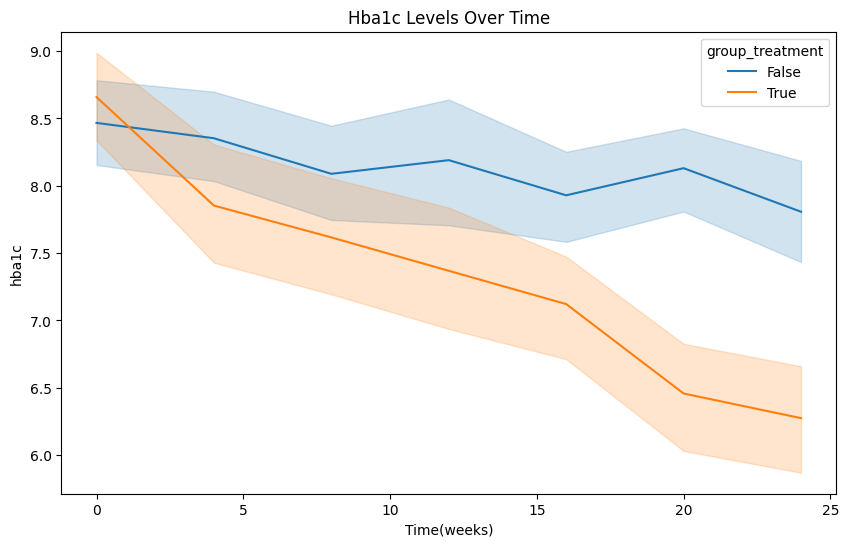

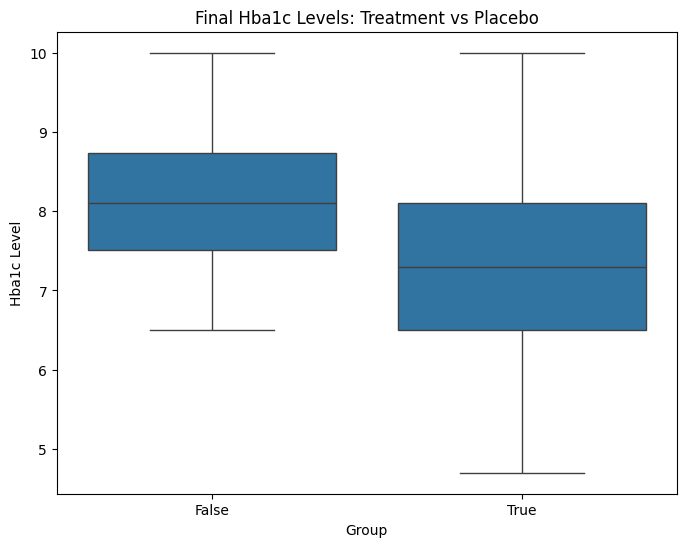

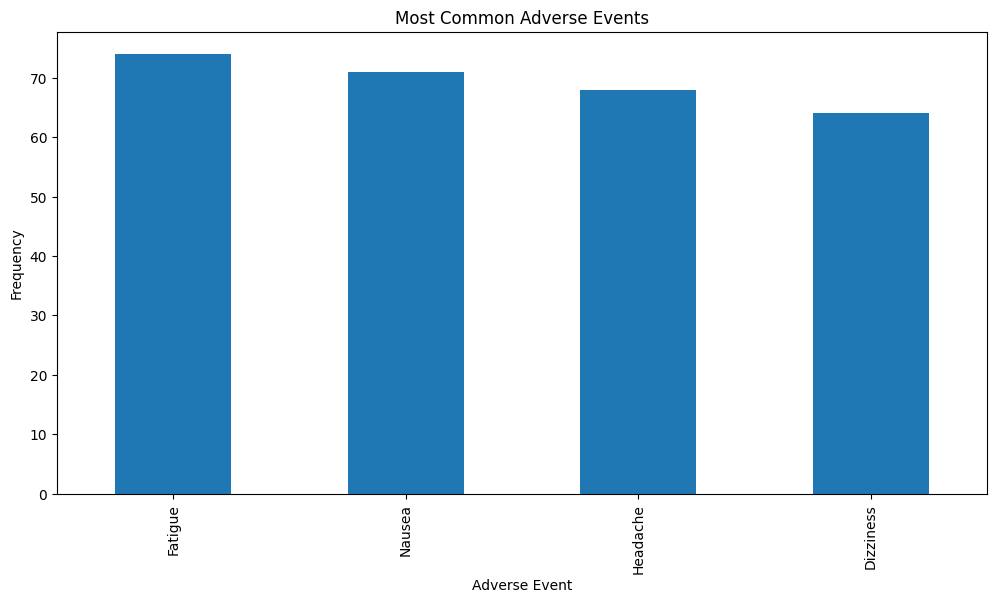

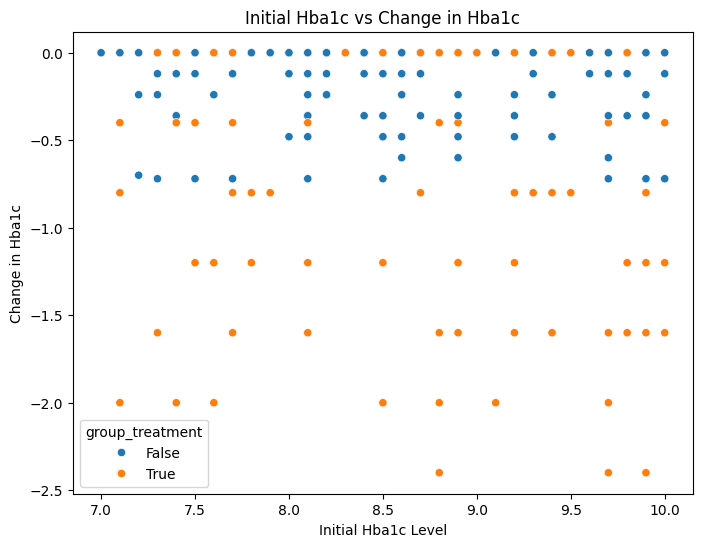

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

#plot Hba1c levels over time with treatment group color coding
plt.figure(figsize=(10,6))
sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
plt.title('Hba1c Levels Over Time')
plt.xlabel('Time(weeks)')
plt.show()


plt.figure(figsize=(8,6))
sns.boxplot(x='group_treatment', y='hba1c', data=df)
plt.title('Final Hba1c Levels: Treatment vs Placebo')
plt.xlabel('Group')
plt.ylabel('Hba1c Level')
plt.show()


plt.figure(figsize=(12,6))
adverse_events.plot(kind='bar')
plt.title('Most Common Adverse Events')
plt.xlabel('Adverse Event')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(x='initial_hba1c', y='hba1c_change', hue='group_treatment', data=df)
plt.title('Initial Hba1c vs Change in Hba1c')
plt.xlabel('Initial Hba1c Level')
plt.ylabel('Change in Hba1c')
plt.show()


<h2 style="color:blue;">Statistical Analysis</h2>

T-test result: t-stat = -6.200485372339337, p_value=2.0550724738165274e-09
                     sum_sq     df          F        PR(>F)
group_treatment   43.836941    1.0  50.782549  9.143732e-12
time              64.254098    1.0  74.434639  5.169343e-16
Residual         236.524596  274.0        NaN           NaN
chi-square test result: chi = 3.453364951919518, p-value = 0.32686108897063443


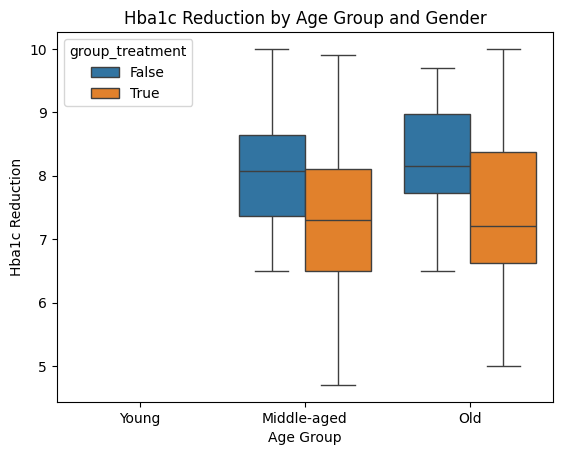

correlation between the Duration of Diabetes and HbA1c Reduction: -0.010949212625554526


In [92]:
# T-test analysis

from scipy import stats

t_stat, p_value = stats.ttest_ind(df[df['group_treatment']==1]['hba1c'], df[df['group_treatment']==0]['hba1c'])
print(f"T-test result: t-stat = {t_stat}, p_value={p_value}")


# perform ANOVA using statsmodels formula API 
import statsmodels.formula.api as smf
import statsmodels.api as sm

model= smf.ols('hba1c ~ time + group_treatment', data=df).fit()
aov_table=  sm.stats.anova_lm(model, typ=2)
print(aov_table)


#use chi-square test to compare adverse event rates between groups
adverse_event_table = pd.crosstab(df['group_treatment'], df['adverse_event'])

#create a contigency table for adverse events by treatment group
chi2, p, dof, expected=stats.chi2_contingency(adverse_event_table, correction=False)
print(f"chi-square test result: chi = {chi2}, p-value = {p}")

# check if 'age-group' column is missing
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 90], labels=['Young', 'Middle-aged', 'Old'])


#create a boxplot for HbA1c by age group and treatment group
sns.boxplot(x='age_group', y='hba1c', hue='group_treatment', data=df)
plt.title('Hba1c Reduction by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Hba1c Reduction')
plt.show()


#calculate the correlation between the duration of diabetes and HbA1c change
correlation = df['duration_diabetes'].corr(df['hba1c_change'])

print(f"correlation between the Duration of Diabetes and HbA1c Reduction: {correlation}")

<h2 style ="color:blue;">Key findings</h2>

<h3 style="color:black;">.Significant Reduction in HbA1c Levels</h3>
<p style="color:black;">The analysis shows that the treatment group experienced a statistically significant reduction in HbA1c levels compared to the Placebo group, confirming the effectiveness of the medication.
<h3 style="color:black;">.Consistent Improvement Over Time</h3>
<p style="color:black">Trends observed in the longitudinal analysis indicate that HbA1c levels decline progressively over time in the treatment group, suggesting sustained treatment benefits</p>
<h3 style="color:black;">.Stronger Impact on High-Risk Patients</h3>
<p style="color:black;">Patients with higher baseline in HbA1c levels exhibited greater reductions, indicating that the medication is particularly effective for individuals with poor initial glycaemic control</p>
<h3 style="color:black;">.Influence of Treatment and Time</h3>
<p style="color:black;">The chi-square analysis indicates that adverse events are significantly associated with thetreatment, suggesting that the medication has a favourable safety profile</p>
<h3 style="color:black;">.Variation Across Patient Demographics</h3>
<p style="color:black;">Differences observed across age groups suggest that treatment effectiveness may vary depending on patient characteristics, supporting the need for personalised treatment approachs</p>
<h3 style="color:black;">.Limited Influence of Disease Duration</h3>
<p style="color:black;">The correlation analysis indicates a weak relationship between duration of diabetes  and HbA1c reduction, suggesting that treatment effectiveness is not strongly dependent on disease duration</p>

<h2 style="color:blue;">Safety Analysis</h2>

<h4 style="color:black;">Safety Analysis in this project focuses on the Chi-square test because it evaluates the association between categorical variables-especially treatment group and adverse event occurrence-making it the most appropriate method for assessing potential safety risks.</h4>
<p style="color:black;">A Chi-square test of independence was conducted to eveluate whether there is an association between the treatment group and the occurrence of adverse events.</p>
<p style="color:black;">The analysis was based on a contingency table comparing the frequency of adverse events between the treatment and placebo groups.The results indicated that the relationship between treatment and adverse events was not statistically significant                            (chi = 3.45336, p-value = 0.32686), that is p >=0.05.This suggests that adverse events occur at a similar rate in both groups, indicating that the medication does not introduce additional safety risks compared to the placebo.</p>
<p style="color:black;">Overall, the findings suggest that the medication demonstrate a safety profile, with no substantial evidence of increased risk beyond expected levels.</p>

<h2 style="color:blue;">Implications</h2>
<h4 style="color:black;">The findings from this analysis have important implications for clinical practice, healthcare decision-making, and future research.</h4>

<h3 style="color:black;">.Clinical Implications</h3>
<p style="color:black;">The statistically significant reduction in HbA1c levels observed in the treatment group indicates that the medication is effective in improving glycaemic control. This suggests that the drug has potential to be adopted as a viable treatment  option for patients with diabetes, particularly those with elevated baseline HbA1c levels who may benefit the most.</p>
<h3 style="color:black;">Patient-Centric Treatment</h3>
<p style="color:black;">The observed variation in treatment effectiveness across patient groups, including differences by age and baseline HbA1c levels, highlights the importance of personalised treatment approaches. Clinicians may consider trailoring treatment strategies based on individual patient characteristics to maximise therapeutic outcomes.</p>
<h3 style="color:black;">Safety and Risk Management</h3>
<p style="color:black;">The safety analysis provides insight into the risk profile of the medication. With no significant association between treatment and adverse events, the findings suggest that the medication is generally useful for use. This is critical for balancing treatment benefits against potential risks in clinical decision-making.</p>
<h3 style="color:black;">Healthcare and Policy Decisions</h3>
<p style="color:black;">Thses results support evidence based decision-making in healthcare settings. If the medication  demonstrates both effectiveness and an acceptable safety profile, it may be considered for  wider clinical use, subject to regulatory approval and further validation.</p>
<h3 style="color:black;">Research and Development</h3>
<p style="color:black;">The analysis highlights areas for further investigations,including long-term treatment effects, broader population studies, and deeper exploration of factors influencing treatment response. This insights can inform future clinical trials and pharmaceutical development strategies.</p>
<h3 style="color:black;">Data-Driven Decision Making</h3>
<p style="color:black;">Overall, this projects demonstrates the value of applying statistical analysis and data visualization techniques in extracting actionable insights from clinical data, supporting informed decisions in both medical and business contexts.</p>


<h2 style="color:blue;">Recommendations</h2>
<h4 style="color:black;">Based on the findings of this analysis, the following recommendations are proposed:</h4>

<h3 style="color:black;">.Clinical Application</h3>
<p style="color:black;">The medication demonstrates strong effectiveness in reducing HbA1c levels and may be considered for wider clinical use, particularly for patients with elevated baseline HbA1c levels who are likely to benefit most from treatment.</p>
<h3 style="color:black;">.Targeted Treatment Strategies</h3>
<p style="color:black;">Given variation in treatment response across patient groups, it is recommended that clinicians adopt a more personalised approach to treatment, taking into account factors such as age and baseline health status.</p>
<h3 style="color:black;">.Safety Monitoring</h3>
<p style="color:black;">Although the safety profile is favourable, it is advisable to continue monitoring adverse events in real-world settings to ensure patient safety and detect any long-term risks.</p>
<h3 style="color:black:">.Further Research</h3>
<h4 style="color:black;">Additional studies should be conducted to:</h4>
<p style="color:black;">.Evaluate long-term effectiveness and safety</p>
<p style="color:black;">.Assess the medication across more diverse populations</p>
<p style="color:black;">.Investigate other factors influencing treatment outcomes</p>
<h3 style="color:black;">.Data-Driven Decision Making</h3>
<p style="color:black;">Healthcare providers and stakeholders are encouraged to incorporate data analytics intp clinical evaluation processes to support evidence-based decision-making and optimise patient outcomes.</p>


<h2 style="color:blue;">Conclusion</h2>

<p style="color:black;">This project analyzed clinical trial data to evaluate the effectiveness and safety of a new diabetes medication using a combination of statistical methods and data visualization techniques.</p>
<p style="color:black;">The results consistently demonstrate that the medication is effective in reducing HbA1c levels, with statistically significant differences observed between the treatment and placebo groups. Visual and statistical analyses further indicate that the treatment effect is sustained over time and may be particularly beneficial for patients with higher baseline HbA1c levels.</p>
<p style="color:black;">The safety analysis provides important insights into risk profile of the medication, showing that the adverse events are not significantly associated with the treatment. This suggests that the medication has a favourable safety profile.</p>
<p style="color:black;">Overall, the findings  support the potential clinical value of the medication as an effective treatment option for improving glycaemic control. This project highlights the importance of combining statistical analysis, data visualization, and domain knowledge to generate meaningful insights that inform healthcare decision-making.</p>